# Week 2 — Unconstrained Optimisation I
## Gradients, Hessians & Convexity

**Optimisation & Mathematical Methods for Economics**
The University of Edinburgh · School of Economics

---

This week we develop the calculus toolkit for optimisation: partial derivatives, the gradient vector, the Hessian matrix, and the crucial concept of convexity.

## 1. Partial Derivatives and the Gradient

For $f: \mathbb{R}^n \to \mathbb{R}$, the **gradient** is the vector of partial derivatives:

$$\nabla f(\mathbf{x}) = \begin{pmatrix} \frac{\partial f}{\partial x_1} \\ \vdots \\ \frac{\partial f}{\partial x_n} \end{pmatrix}$$

The gradient points in the direction of steepest ascent. At a local optimum, $\nabla f(\mathbf{x}^*) = \mathbf{0}$ (first-order necessary condition).

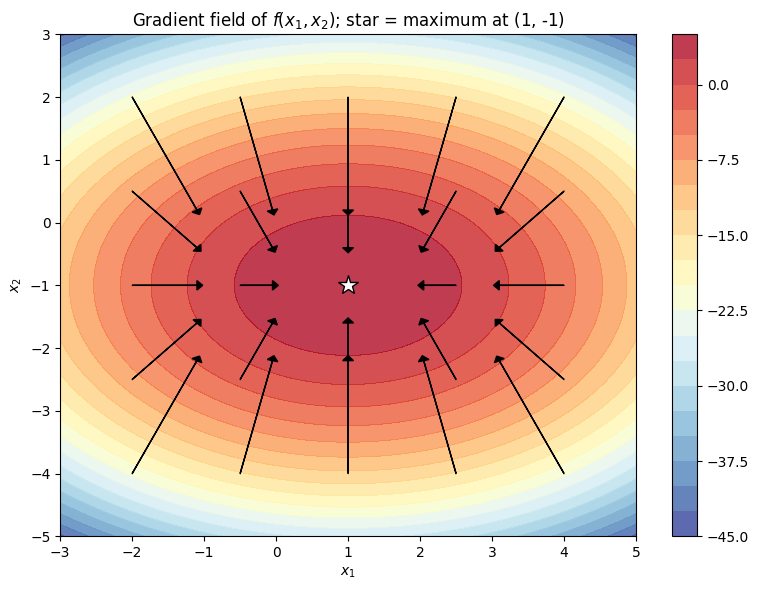

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Example: f(x1, x2) = -(x1 - 1)^2 - 2(x2 + 1)^2 + 5
# Gradient: [-2(x1-1), -4(x2+1)]
def f(x1, x2):
    return -(x1 - 1)**2 - 2*(x2 + 1)**2 + 5

def grad_f(x1, x2):
    return np.array([-2*(x1 - 1), -4*(x2 + 1)])

# Plot function with gradient arrows
x1 = np.linspace(-3, 5, 100)
x2 = np.linspace(-5, 3, 100)
X1, X2 = np.meshgrid(x1, x2)
Z = f(X1, X2)

fig, ax = plt.subplots(figsize=(8, 6))
cp = ax.contourf(X1, X2, Z, levels=20, cmap='RdYlBu_r', alpha=0.8)
plt.colorbar(cp, ax=ax)

# Gradient vectors at a grid of points
for xi in np.linspace(-2, 4, 5):
    for xj in np.linspace(-4, 2, 5):
        g = grad_f(xi, xj)
        ax.arrow(xi, xj, g[0]*0.15, g[1]*0.15,
                head_width=0.15, head_length=0.08, fc='black', ec='black')

ax.plot(1, -1, 'w*', markersize=15, markeredgecolor='black')
ax.set_title('Gradient field of $f(x_1,x_2)$; star = maximum at (1, -1)', fontsize=12)
ax.set_xlabel('$x_1$'); ax.set_ylabel('$x_2$')
plt.tight_layout()
plt.show()

## 2. The Hessian Matrix

The **Hessian** is the matrix of second partial derivatives:

$$H_f(\mathbf{x}) = \begin{pmatrix} \frac{\partial^2 f}{\partial x_1^2} & \frac{\partial^2 f}{\partial x_1 \partial x_2} \\ \frac{\partial^2 f}{\partial x_2 \partial x_1} & \frac{\partial^2 f}{\partial x_2^2} \end{pmatrix}$$

**Second-order conditions** at a critical point $\mathbf{x}^*$ where $\nabla f = 0$:
- $H$ negative definite $\Rightarrow$ local **maximum**
- $H$ positive definite $\Rightarrow$ local **minimum**
- $H$ indefinite $\Rightarrow$ **saddle point**

In [2]:
# Classify critical points using the Hessian
# f(x,y) = x^3 - 3xy^2  (monkey saddle has critical point at origin)
# f(x,y) = x^2 + y^2     (minimum at origin)
# f(x,y) = -(x^2 + y^2)  (maximum at origin)

examples = {
    "x^2 + y^2 (minimum)": np.array([[2, 0], [0, 2]]),
    "-(x^2 + y^2) (maximum)": np.array([[-2, 0], [0, -2]]),
    "x^2 - y^2 (saddle)": np.array([[2, 0], [0, -2]]),
}

for name, H in examples.items():
    eigvals = np.linalg.eigvalsh(H)
    if all(eigvals > 0):
        result = "Local MINIMUM (H positive definite)"
    elif all(eigvals < 0):
        result = "Local MAXIMUM (H negative definite)"
    else:
        result = "SADDLE POINT (H indefinite)"
    print(f"f = {name}")
    print(f"  H = {H.tolist()}, eigenvalues = {eigvals}")
    print(f"  => {result}\n")

f = x^2 + y^2 (minimum)
  H = [[2, 0], [0, 2]], eigenvalues = [2. 2.]
  => Local MINIMUM (H positive definite)

f = -(x^2 + y^2) (maximum)
  H = [[-2, 0], [0, -2]], eigenvalues = [-2. -2.]
  => Local MAXIMUM (H negative definite)

f = x^2 - y^2 (saddle)
  H = [[2, 0], [0, -2]], eigenvalues = [-2.  2.]
  => SADDLE POINT (H indefinite)



## 3. Convexity and Concavity

A function $f$ is **convex** if for all $\mathbf{x}, \mathbf{y}$ and $\lambda \in [0,1]$:
$$f(\lambda \mathbf{x} + (1-\lambda)\mathbf{y}) \leq \lambda f(\mathbf{x}) + (1-\lambda) f(\mathbf{y})$$

Geometrically: the line segment between any two points on the graph lies above (or on) the graph.

**Key result:** If $f$ is convex, then every local minimum is a **global** minimum. If $f$ is concave, every local maximum is a global maximum.

**Characterisation via the Hessian:** If $f$ is twice differentiable, $f$ is convex $\iff H_f(\mathbf{x})$ is positive semi-definite for all $\mathbf{x}$.

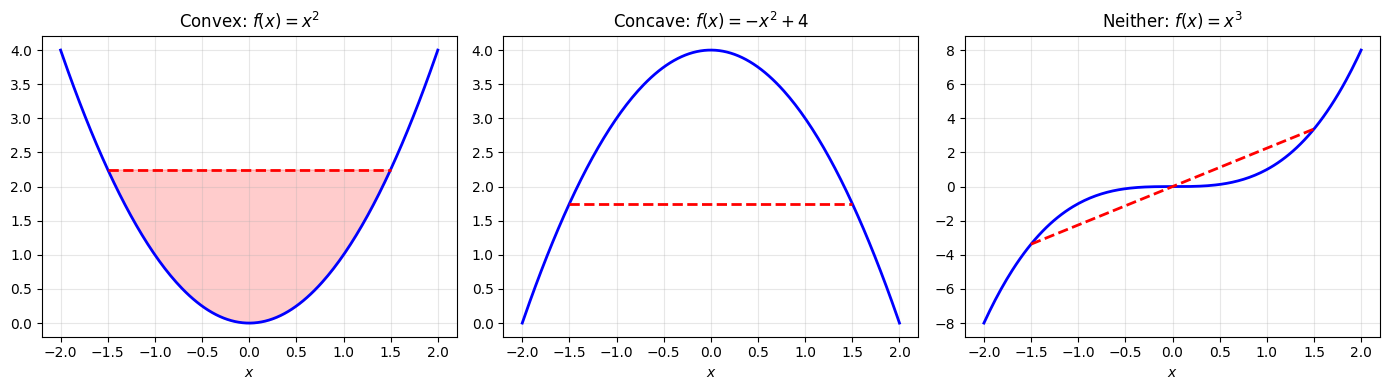

In [3]:
# Visualising convexity
x = np.linspace(-2, 2, 200)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# Convex function
axes[0].plot(x, x**2, 'b-', linewidth=2)
# Secant line between (-1.5, 2.25) and (1.5, 2.25)
axes[0].plot([-1.5, 1.5], [(-1.5)**2, (1.5)**2], 'r--', linewidth=2)
axes[0].fill_between(x[(x>=-1.5)&(x<=1.5)],
                     x[(x>=-1.5)&(x<=1.5)]**2,
                     np.interp(x[(x>=-1.5)&(x<=1.5)], [-1.5,1.5], [2.25,2.25]),
                     alpha=0.2, color='red')
axes[0].set_title('Convex: $f(x)=x^2$', fontsize=12)

# Concave function
axes[1].plot(x, -x**2 + 4, 'b-', linewidth=2)
axes[1].plot([-1.5, 1.5], [-(-1.5)**2+4, -(1.5)**2+4], 'r--', linewidth=2)
axes[1].set_title('Concave: $f(x)=-x^2+4$', fontsize=12)

# Neither
axes[2].plot(x, x**3, 'b-', linewidth=2)
axes[2].plot([-1.5, 1.5], [(-1.5)**3, (1.5)**3], 'r--', linewidth=2)
axes[2].set_title('Neither: $f(x)=x^3$', fontsize=12)

for ax in axes:
    ax.set_xlabel('$x$')
    ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 4. Economic Application: Profit Maximisation

A firm has revenue $R(q) = pq$ and cost $C(q) = q^3 - 6q^2 + 15q + 10$.

Profit: $\pi(q) = pq - C(q)$

**First-order condition:** $\pi'(q) = p - C'(q) = 0 \Rightarrow p = MC(q)$

**Second-order condition:** $\pi''(q) = -C''(q) < 0 \Rightarrow C''(q) > 0$ (increasing marginal cost)

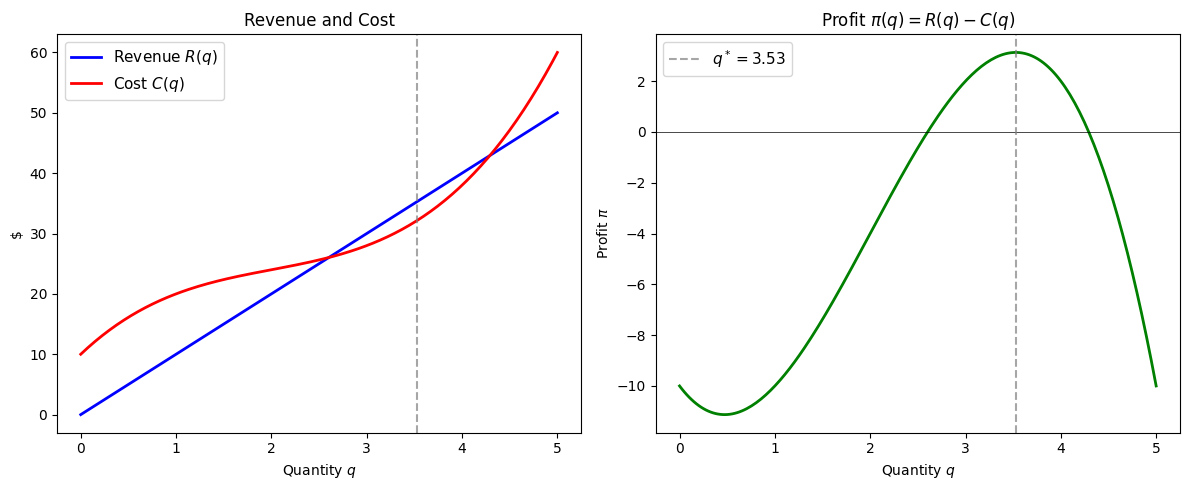

Optimal quantity: q* = 3.5275
Maximum profit: pi* = 3.1285


In [4]:
# Profit maximisation
p = 10  # price

q = np.linspace(0, 5, 200)
C = q**3 - 6*q**2 + 15*q + 10
R = p * q
profit = R - C

# FOC: p - (3q^2 - 12q + 15) = 0  =>  3q^2 - 12q + (15 - p) = 0
a, b, c = 3, -12, (15 - p)
q_star = (-b + np.sqrt(b**2 - 4*a*c)) / (2*a)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].plot(q, R, 'b-', label='Revenue $R(q)$', linewidth=2)
axes[0].plot(q, C, 'r-', label='Cost $C(q)$', linewidth=2)
axes[0].axvline(q_star, color='gray', linestyle='--', alpha=0.7)
axes[0].legend(fontsize=11)
axes[0].set_xlabel('Quantity $q$'); axes[0].set_ylabel('$')
axes[0].set_title('Revenue and Cost')

axes[1].plot(q, profit, 'g-', linewidth=2)
axes[1].axhline(0, color='black', linewidth=0.5)
axes[1].axvline(q_star, color='gray', linestyle='--', alpha=0.7, label=f'$q^* = {q_star:.2f}$')
axes[1].set_xlabel('Quantity $q$'); axes[1].set_ylabel('Profit $\pi$')
axes[1].set_title('Profit $\pi(q) = R(q) - C(q)$')
axes[1].legend(fontsize=11)

plt.tight_layout()
plt.show()
print(f"Optimal quantity: q* = {q_star:.4f}")
print(f"Maximum profit: pi* = {p*q_star - (q_star**3 - 6*q_star**2 + 15*q_star + 10):.4f}")

## Exercises

<details><summary><b>Exercise 1:</b> Find the gradient and Hessian of $f(x,y) = x^2 y + xy^2 - 3xy$. Locate and classify the critical points.</summary>

```python
# Gradient: [2xy + y^2 - 3y, x^2 + 2xy - 3x]
# Setting both to zero and solving:
# y(2x + y - 3) = 0 and x(x + 2y - 3) = 0
# Critical points: (0,0), (3,0), (0,3), (1,1)
# Check the Hessian at each to classify.
from scipy.optimize import fsolve
# ... (students work through this analytically and verify numerically)
```
</details>

<details><summary><b>Exercise 2:</b> Show that $f(x) = e^x$ is convex by verifying the Hessian (second derivative) condition.</summary>

$f''(x) = e^x > 0$ for all $x$, so $f$ is strictly convex everywhere.
</details>